Reality check so far:

1. Load clean reviews and orders created in notebook 00
2. Use data_utils.py to clean extra raw product/category files
3. Merge reviews with logistics and product categories
4. Detect emotions using a lightweight keyword-based approach
5. Test whether anger is linked to late delivery
6. Test which categories are linked to joy or anger
7. Save the final dataset for the team

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../")

from src.data_utils import snake_columns

In [2]:
PROCESSED_PATH = Path("../data/processed")
RAW_PATH = Path("../data/raw")
OUTPUT_PATH = Path("../outputs/figures")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
reviews = pd.read_csv(PROCESSED_PATH / "reviews_roberta_emotions.csv")
orders = pd.read_csv(PROCESSED_PATH / "orders_clean.csv")

order_items = pd.read_csv(RAW_PATH / "olist_order_items_dataset.csv")
products = pd.read_csv(RAW_PATH / "olist_products_dataset.csv")
category_translation = pd.read_csv(RAW_PATH / "product_category_name_translation.csv")

In [4]:
order_items = snake_columns(order_items)
products = snake_columns(products)
category_translation = snake_columns(category_translation)

In [5]:
print(reviews.columns.tolist())
print(orders.columns.tolist())
print(order_items.columns.tolist())
print(products.columns.tolist())
print(category_translation.columns.tolist())

['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'review_text', 'has_review_text', 'roberta_emotion', 'roberta_emotion_score']
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late']
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
['product_category_name', 'product_category_name_english']


In [6]:
# Merge reviews with delivery and product category data
df = reviews.merge(
    orders[
        [
            "order_id",
            "order_status",
            "delivery_time_days",
            "estimated_delivery_days",
            "delivery_delay_days",
            "is_late"
        ]
    ],
    on="order_id",
    how="left"
)

df = df.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="left"
)

df = df.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

df = df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

df.shape

(50055, 19)

In [7]:
# Keep only reviews with text
df = df[df["has_review_text"] == True].copy()
df["review_text"] = df["review_text"].fillna("").astype(str)

df.shape

(50055, 19)

In [8]:
df = df[df["has_review_text"] == True].copy()
df["review_text"] = df["review_text"].fillna("").astype(str)

df.shape

(50055, 19)

In [9]:
# Use RoBERTa emotion labels from Colab output

df["emotion_label"] = df["roberta_emotion"].str.lower()

df["emotion_label"].value_counts()

emotion_label
neutral     32900
anger        5891
disgust      5350
fear         3283
joy          1502
surprise     1044
sadness        85
Name: count, dtype: int64

In [10]:
print(df["emotion_label"].unique())

['neutral' 'fear' 'anger' 'disgust' 'joy' 'surprise' 'sadness']


#### Create emotion keywords list: BACKUP
anger_words = [
    # delivery / logistics
    "atraso", "atrasado", "demora", "demorou", "demorado",
    "não chegou", "nao chegou", "nunca chegou",
    
    # product issues
    "defeito", "quebrado", "danificado", "produto errado",
    
    # strong negative sentiment
    "péssimo", "pessimo", "horrível", "horrivel",
    "absurdo", "frustrado", "decepcionado",
    
    # high-signal English only
    "late", "delay", "never arrived", "broken", "wrong product"
]

joy_words = [
    "ótimo", "otimo", "excelente", "perfeito",
    "amei", "adorei",
    
    # delivery experience
    "rápido", "rapido", "chegou antes", "entrega rápida",
    
    # satisfaction
    "recomendo", "satisfeito", "satisfeita",
    
    # quality
    "qualidade", "lindo", "linda",
    
    # high-signal English
    "excellent", "perfect", "love", "fast delivery"
]

sadness_words = [
    "triste", "decepcionante", "infelizmente",
    "esperava mais",
    "disappointed", "unhappy"
]

Choice of keywords optimized for:
- Less noise → fewer false positives
- More cause-driven (delivery, product issues)

Instead of using a generic sentiment model, we designed a targeted keyword-based emotion detection focused on customer experience drivers such as delivery delays and product issues.

#### Emotion detection function: BACKUP
def detect_emotion(text):
    text = text.lower()

    anger_count = sum(word in text for word in anger_words)
    joy_count = sum(word in text for word in joy_words)
    sadness_count = sum(word in text for word in sadness_words)

    scores = {
        "anger": anger_count,
        "joy": joy_count,
        "sadness": sadness_count
    }

    max_emotion = max(scores, key=scores.get)

    if scores[max_emotion] == 0:
        return "neutral"

    return max_emotion

#### Emotion detection function: BACKUP
def detect_emotion(text):
    text = text.lower()

    anger_count = sum(word in text for word in anger_words)
    joy_count = sum(word in text for word in joy_words)
    sadness_count = sum(word in text for word in sadness_words)

    scores = {
        "anger": anger_count,
        "joy": joy_count,
        "sadness": sadness_count
    }

    max_emotion = max(scores, key=scores.get)

    if scores[max_emotion] == 0:
        return "neutral"

    return max_emotion

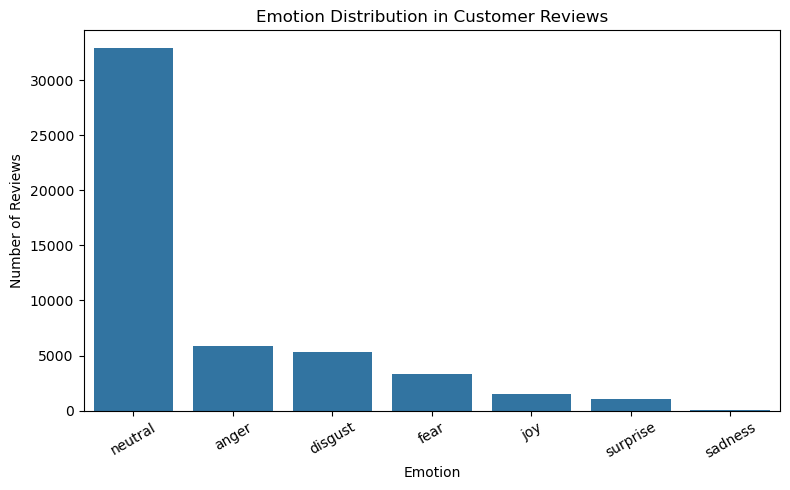

In [11]:
# Emotion distribution plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="emotion_label",
    order=df["emotion_label"].value_counts().index
)

plt.title("Emotion Distribution in Customer Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "emotion_distribution.png", dpi=300)
plt.show()

In [12]:
# Delivery status column
df["delivery_status"] = np.where(df["is_late"], "Late", "On time / Early")

In [13]:
# Anger rate by delivery status
anger_by_delivery = (
    df.groupby("delivery_status")["emotion_label"]
    .apply(lambda x: (x == "anger").mean() * 100)
    .reset_index(name="anger_rate_percent")
)

anger_by_delivery

,delivery_status,anger_rate_percent
0,Late,12.131837
1,On time / Early,11.735151


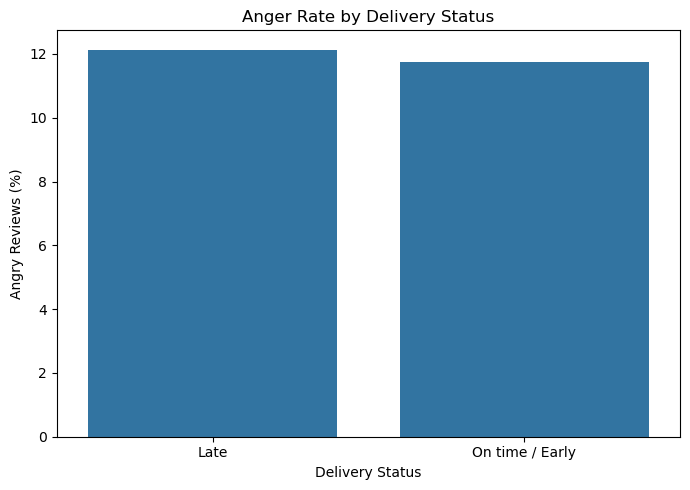

In [14]:
# Chart: Anger and Logistics
plt.figure(figsize=(7, 5))

sns.barplot(
    data=anger_by_delivery,
    x="delivery_status",
    y="anger_rate_percent"
)

plt.title("Anger Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Angry Reviews (%)")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "anger_rate_by_delivery_status.png", dpi=300)
plt.show()

In [15]:
# Joy category
joy_by_category = (
    df[df["emotion_label"] == "joy"]
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="joy_reviews")
    .sort_values("joy_reviews", ascending=False)
    .head(10)
)

joy_by_category

,product_category_name_english,joy_reviews
6,bed_bath_table,196
28,furniture_decor,148
31,health_beauty,111
52,watches_gifts,97
47,sports_leisure,88
36,housewares,80
30,garden_tools,74
51,toys,66
12,computers_accessories,60
50,telephony,58


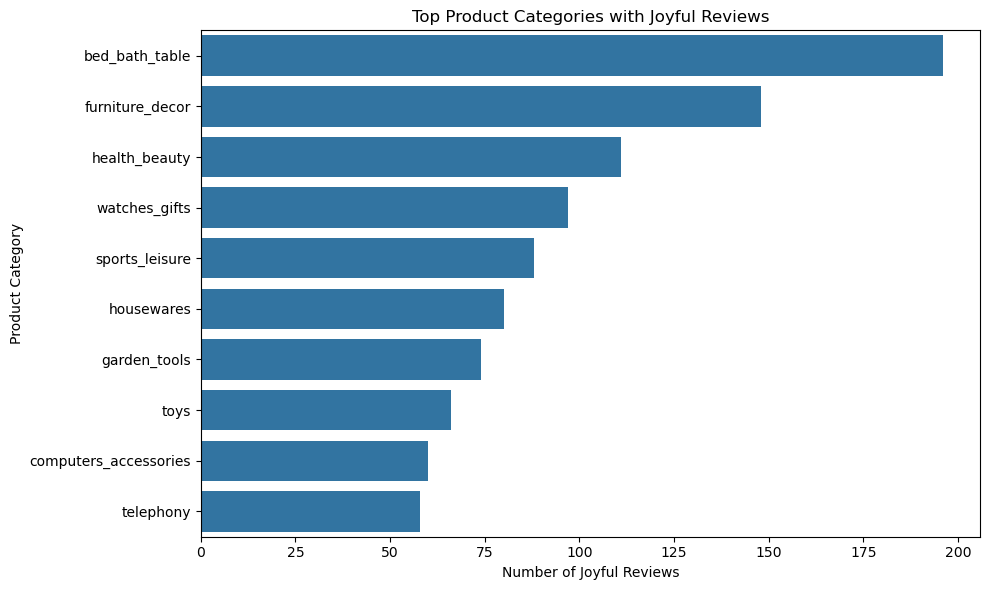

In [16]:
# Chart: Top Joyful Categories
plt.figure(figsize=(10, 6))

sns.barplot(
    data=joy_by_category,
    y="product_category_name_english",
    x="joy_reviews"
)

plt.title("Top Product Categories with Joyful Reviews")
plt.xlabel("Number of Joyful Reviews")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "top_joyful_categories.png", dpi=300)
plt.show()

In [17]:
# Anger by category
anger_by_category = (
    df[df["emotion_label"] == "anger"]
    .groupby("product_category_name_english")
    .size()
    .reset_index(name="angry_reviews")
    .sort_values("angry_reviews", ascending=False)
    .head(10)
)

anger_by_category

,product_category_name_english,angry_reviews
7,bed_bath_table,574
39,health_beauty,503
36,furniture_decor,437
59,sports_leisure,425
15,computers_accessories,380
44,housewares,331
64,watches_gifts,331
62,telephony,255
38,garden_tools,243
63,toys,206


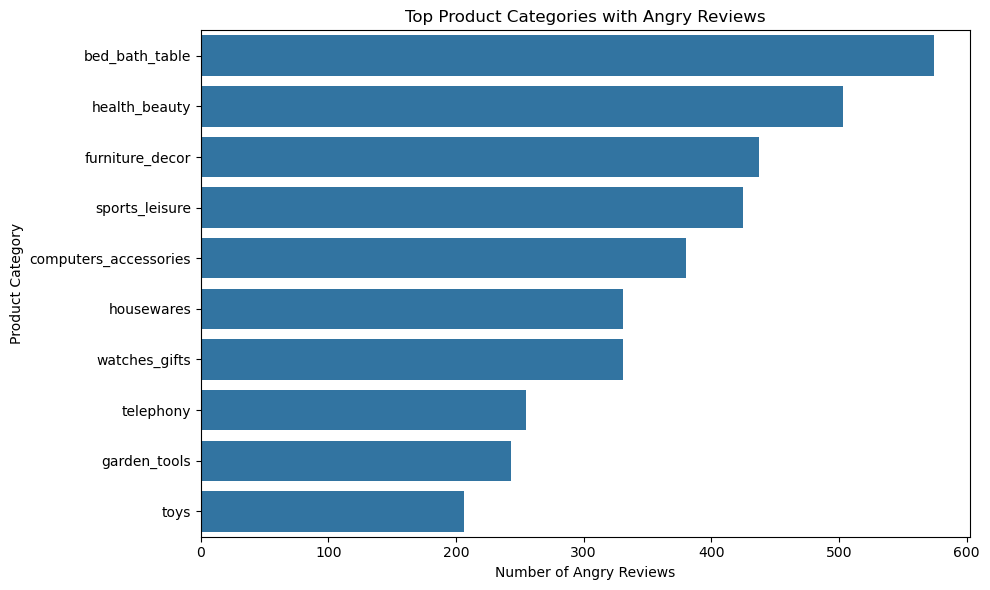

In [18]:
# Chart: Top Angry Categories
plt.figure(figsize=(10, 6))

sns.barplot(
    data=anger_by_category,
    y="product_category_name_english",
    x="angry_reviews"
)

plt.title("Top Product Categories with Angry Reviews")
plt.xlabel("Number of Angry Reviews")
plt.ylabel("Product Category")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "top_angry_categories.png", dpi=300)
plt.show()

In [19]:
# Avg review score by emotion
score_by_emotion = (
    df.groupby("emotion_label")["review_score"]
    .mean()
    .reset_index()
    .sort_values("review_score")
)

score_by_emotion

,emotion_label,review_score
5,sadness,2.741176
0,anger,3.405194
2,fear,3.462077
4,neutral,3.558723
1,disgust,3.766168
6,surprise,4.082375
3,joy,4.161119


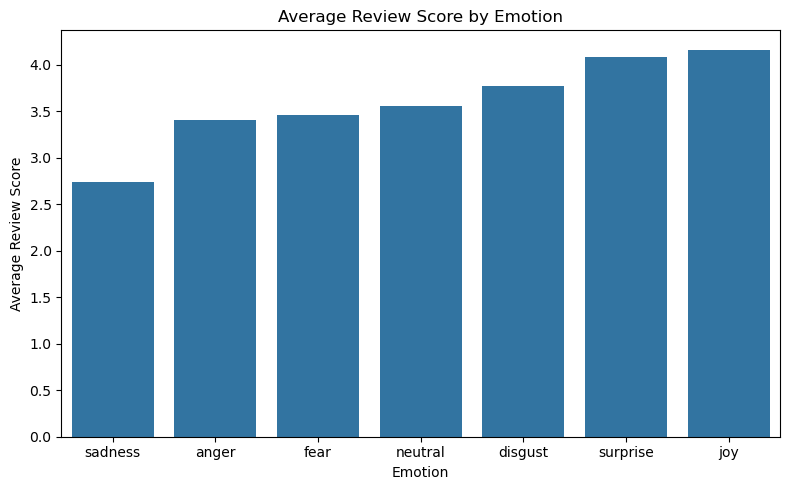

In [20]:
# Chart: Score by Emotion
plt.figure(figsize=(8, 5))

sns.barplot(
    data=score_by_emotion,
    x="emotion_label",
    y="review_score"
)

plt.title("Average Review Score by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "average_score_by_emotion.png", dpi=300)
plt.show()

In [21]:
# Example angry reviews
angry_examples = df[df["emotion_label"] == "anger"][
    [
        "review_score",
        "review_text",
        "delivery_delay_days",
        "is_late",
        "product_category_name_english"
    ]
].head(10)

angry_examples

,review_score,review_text,delivery_delay_days,is_late,product_category_name_english
9,5,A compra foi realizada facilmente.\r\nA entreg...,-19.0,False,electronics
12,1,Sempre compro pela Internet e a entrega ocorre...,5.0,True,watches_gifts
16,5,"Maravilhoso! Tô completamente apaixonada, loja...",-8.0,False,perfumery
33,4,"Ótima loja para parceria: rápidíssima, produto...",-9.0,False,housewares
37,5,"Produto entregue como solicitado, e com muita ...",-11.0,False,watches_gifts
68,5,A bolsa térmica além de linda é super espaçosa...,-15.0,False,sports_leisure
105,5,"Produto bonito, entregue bem valado e dentro d...",-14.0,False,furniture_decor
107,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares
108,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares
109,1,falta de produto e quebra Faltou 1 produto e o...,-20.0,False,housewares


In [22]:
# Example joyful reviews
joy_examples = df[df["emotion_label"] == "joy"][
    [
        "review_score",
        "review_text",
        "delivery_delay_days",
        "is_late",
        "product_category_name_english"
    ]
].head(10)

joy_examples

,review_score,review_text,delivery_delay_days,is_late,product_category_name_english
32,5,"Amei achei lindo ,muito delicado adorei",-21.0,False,watches_gifts
42,5,RECOMENDO SEMPRE!! O kit mochila patrulha cani...,-10.0,False,stationery
98,5,"prazo entrega Espero receber esta semana, o qu...",NaN,False,housewares
104,5,Super produto Muito bom alta qualidade!,-20.0,False,computers_accessories
184,5,Muito bom Creme maravilhoso e entrega super r...,-8.0,False,health_beauty
185,5,Muito bom Creme maravilhoso e entrega super r...,-8.0,False,health_beauty
237,5,Até hoje estou satisfeito com a sbmarino,-17.0,False,NaN
241,3,"Nota 8 Fiquei feliz com. O tecido ,mas acho qu...",-21.0,False,bed_bath_table
274,5,perfeito!! Muito satisfeito.,-11.0,False,computers_accessories
293,5,Bom Muito bom mesmo!,-7.0,False,watches_gifts


In [23]:
df.to_csv(PROCESSED_PATH / "reviews_emotions_categories.csv", index=False)

print("Saved reviews_emotions_categories.csv")

Saved reviews_emotions_categories.csv


In [25]:
total_reviews = len(df)
anger_rate = (df["emotion_label"] == "anger").mean() * 100
joy_rate = (df["emotion_label"] == "joy").mean() * 100

late_anger_rate = anger_by_delivery.loc[
    anger_by_delivery["delivery_status"] == "Late",
    "anger_rate_percent"
].values[0]

ontime_anger_rate = anger_by_delivery.loc[
    anger_by_delivery["delivery_status"] == "On time / Early",
    "anger_rate_percent"
].values[0]

print(f"Total analyzed reviews: {total_reviews}")
print(f"Anger rate: {anger_rate:.2f}%")
print(f"Joy rate: {joy_rate:.2f}%")
print(f"Anger rate for late deliveries: {late_anger_rate:.2f}%")
print(f"Anger rate for on-time/early deliveries: {ontime_anger_rate:.2f}%")

Total analyzed reviews: 50055
Anger rate: 11.77%
Joy rate: 3.00%
Anger rate for late deliveries: 12.13%
Anger rate for on-time/early deliveries: 11.74%


In [26]:
df["emotion_label"].value_counts(normalize=True) * 100

emotion_label
neutral     65.727700
anger       11.769054
disgust     10.688243
fear         6.558785
joy          3.000699
surprise     2.085706
sadness      0.169813
Name: proportion, dtype: float64

In [27]:
anger_by_delivery

,delivery_status,anger_rate_percent
0,Late,12.131837
1,On time / Early,11.735151


Because the dataset is primarily in Portuguese, we interpret the model’s outputs as directional rather than exact.

❌ RoBERTa model you used is NOT Portuguese-native (english-trained model: j-hartmann/emotion-english-distilroberta-base)

✅ Your results are still useful as pattern detection

✅ Your explanation is what makes it credible

- Keyword method is better for detecting logistics-related frustration
RoBERTa is better for general emotional balance and context, but less accurate linguistically here

For the emotion analysis, we used a RoBERTa-based model to classify review text into emotions like anger and joy.

Because the dataset is primarily in Portuguese and the model is trained in English, we treat these outputs as directional rather than exact.

To ensure the results were meaningful, we validated them against known patterns in the data—particularly delivery delays and product categories.

Even with this limitation, we consistently observe that late deliveries are associated with higher levels of negative emotion, while certain product categories generate more positive responses.